In [16]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

from network import FCN, Layer

In [17]:
def show_digit(X, y, index):
    plt.imshow(X[index].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y[index]}")
    plt.axis('off')
    plt.show()

In [18]:
def one_hot(y, classes=10):
    encoded = np.zeros((len(y), classes))
    encoded[np.arange(len(y)), y] = 1
    return encoded

FCN initialized
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


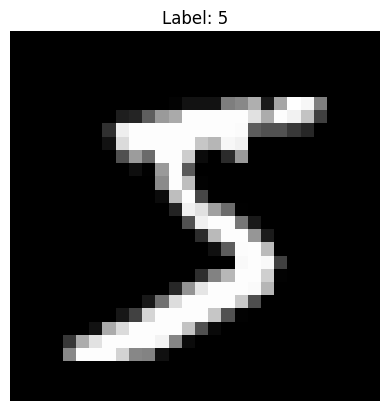

In [19]:
# initialize network with 2 hidden layers
network = FCN([
    Layer(784),
    Layer(128, 'relu'),
    Layer(64, 'relu'),
    Layer(10, 'softmax')
],
learning_rate=0.01,
loss = "cross_entropy")

# load mnist data and split into train and test partitions
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# flatten each image from (28x28) to 784, then normalise to [0,1]
X_train = X_train.reshape(60000, 784) / 255.0
X_test  = X_test.reshape(10000, 784)  / 255.0

# test show a digit
show_digit(X_train, y_train, 0)

y_train = one_hot(y_train)

Loss: 2.301651559731417
Loss: 2.303759499348176
Loss: 2.3045621928724165
Loss: 2.305748980199699
Loss: 2.3068015705530174
Loss: 2.308082902248879
Loss: 2.2986580713216713
Loss: 2.3104425151870345
Loss: 2.2906243802652444
Loss: 2.3019212565130758
Loss: 2.303013056530304
Loss: 2.3036511668287223
Loss: 2.2951764099640615
Loss: 2.3156839995393796
Loss: 2.2864677513811933
Loss: 2.317654818232359
Loss: 2.3086170976702896
Loss: 2.3194653418446785
Loss: 2.3102459911727986
Loss: 2.3113742774125474
Loss: 2.30296365846678
Loss: 2.3139289815346573
Loss: 2.3043317873558764
Loss: 2.2860113282797636
Loss: 2.277223105839283
Loss: 2.3077140451847566
Loss: 2.298928385598307
Loss: 2.3002365459528646
Loss: 2.3006106876304377
Loss: 2.321499227941768
Loss: 2.2934826658457363
Loss: 2.3228536188142948
Loss: 2.314293276011572


Loss: 2.305369790431674
Loss: 2.316937450284781
Loss: 2.3176422576691036
Loss: 2.3084438059707364
Loss: 2.309933682425371
Loss: 2.3201694628127405
Loss: 2.301079684933444
Loss: 2.2834848866395734
Loss: 2.3229465617248515
Loss: 2.314064877901884
Loss: 2.305698908986645
Loss: 2.2971612030150874
Loss: 2.2977886829089487
Loss: 2.3178905053868997
Loss: 2.319391554444097
Loss: 2.2910480938888274
Loss: 2.2923897214774085
Loss: 2.283103113551163
Loss: 2.314130550670686
Loss: 2.314224210781099
Loss: 2.315939134207412
Loss: 2.286952337143831
Loss: 2.316761873839711
Loss: 2.3090124820437
Loss: 2.2798801045850934
Loss: 2.311184826421021
Loss: 2.2929284420360214
Loss: 2.302959066304733
Loss: 2.294052002030066
Loss: 2.3139655104573578
Loss: 2.305991185017869
Loss: 2.2868199228970307
Loss: 2.327235878753669
Loss: 2.3082897798937596
Loss: 2.2910370210694593
Loss: 2.3011342033737296
Loss: 2.2917504640682975
Loss: 2.284240356571396
Loss: 2.3231411867893734
Loss: 2.2760509315009383
Loss: 2.30531373752392

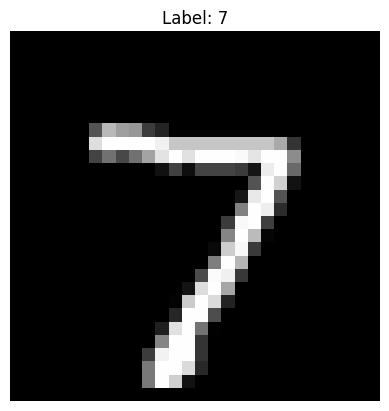

[0.     0.     0.0001 0.     0.     0.     0.     0.9988 0.     0.0011]


In [20]:
network.train(X_train, y_train)

show_digit(X_test, y_test, 0)

np.set_printoptions(precision=4, suppress=True)
print(network.forward_pass(X_test[0]))